In [2]:
import numpy as np
import matplotlib.pyplot as plt

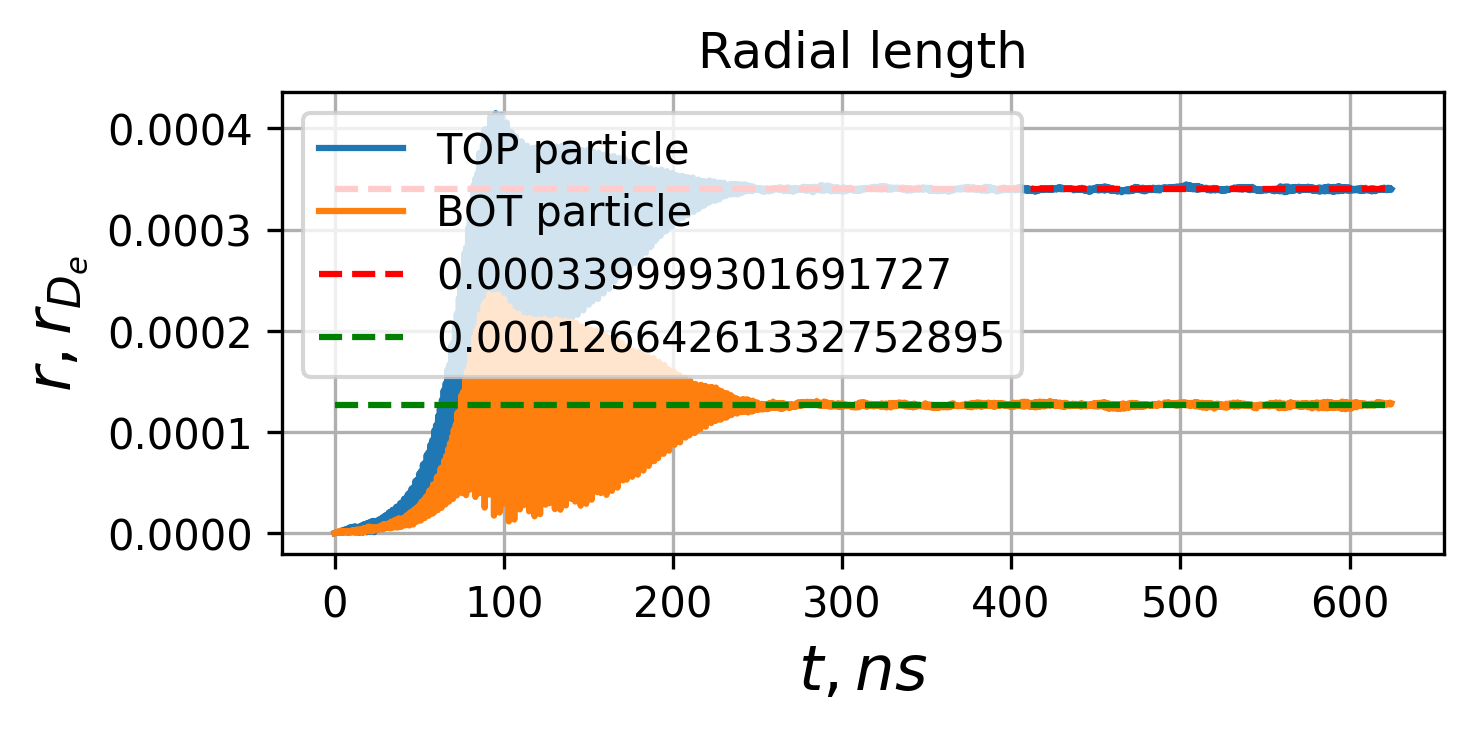

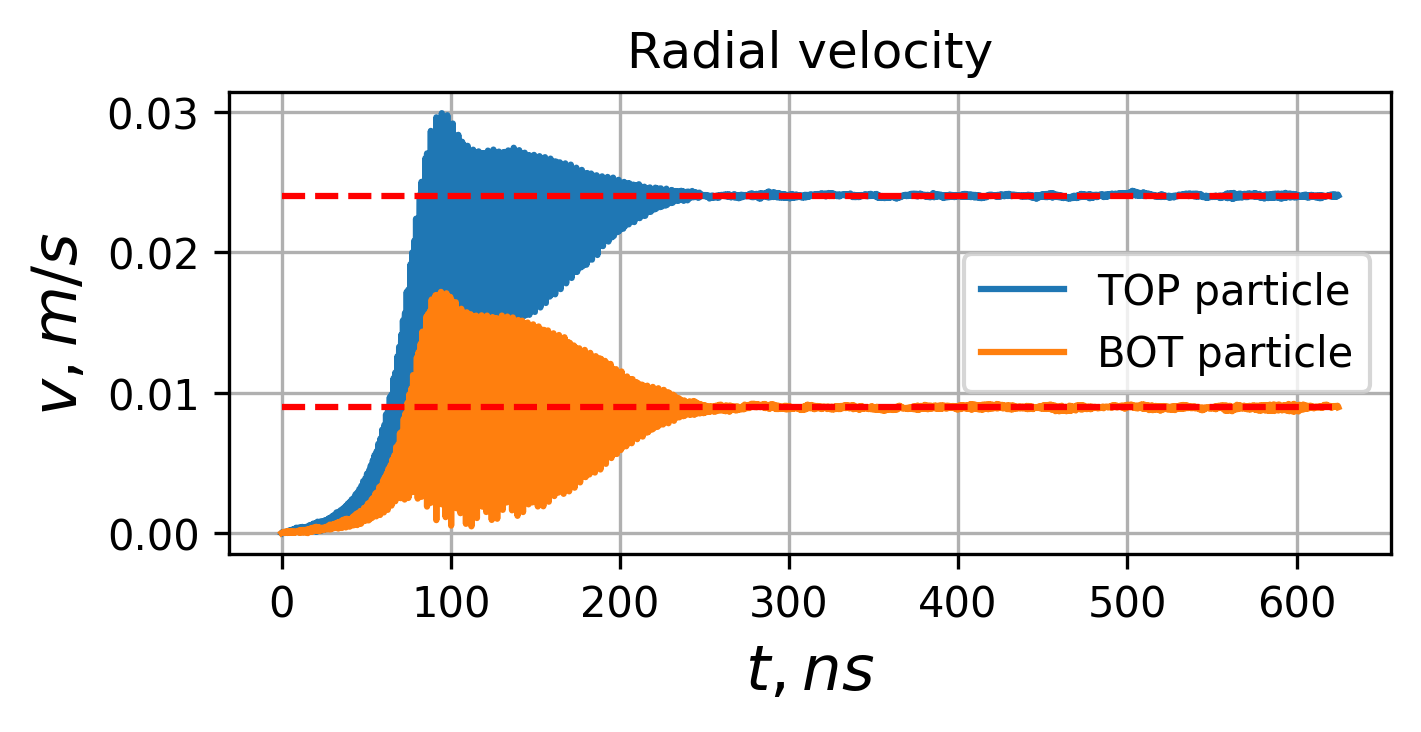

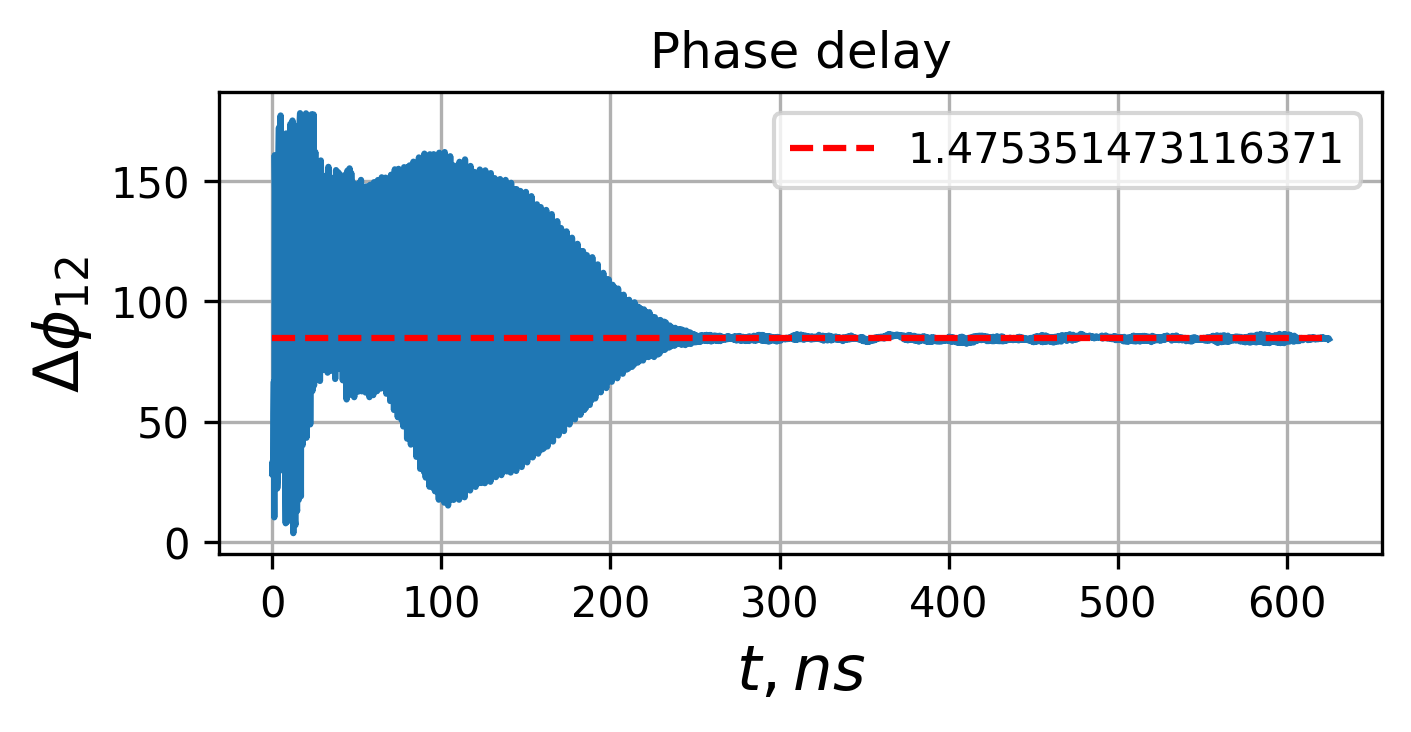

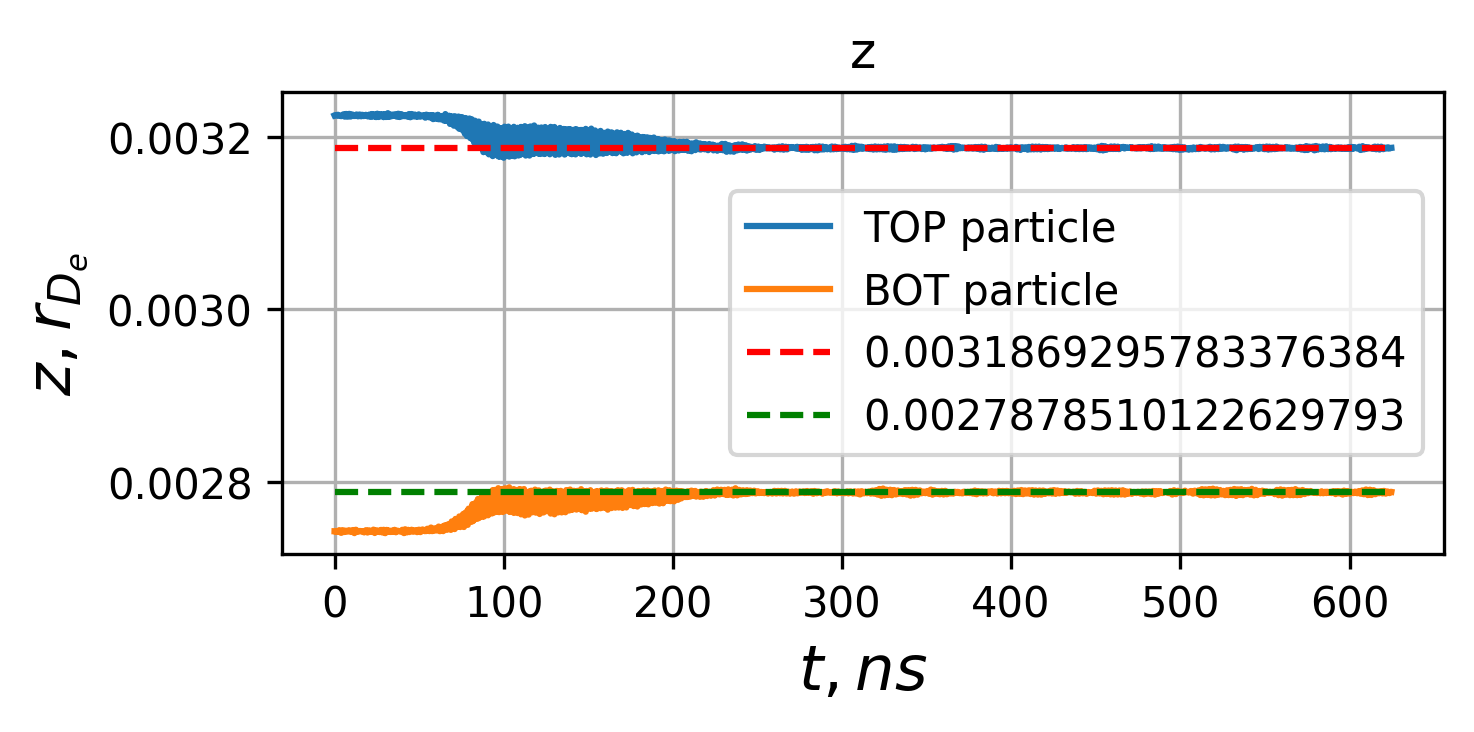

In [3]:
data = np.genfromtxt(f"../data/dynamics/data.txt", delimiter="\t")

rs_1 = np.sqrt(np.square(data[:, 1]) + np.square(data[:, 2]))
rs_2 = np.sqrt(np.square(data[:, 4]) + np.square(data[:, 5]))

xs_1 = data[:, 1]
xs_2 = data[:, 4]

ys_1 = data[:, 2]
ys_2 = data[:, 5]

zs_1 = data[:, 3]
zs_2 = data[:, 6]

vs_1 = np.sqrt(np.square(data[:, 7]) + np.square(data[:, 8]))
vs_2 = np.sqrt(np.square(data[:, 7 + 3]) + np.square(data[:, 8 + 3]))


t = (data[:, 0]) / 2.0 * 50.0
t_min = np.min(t)
t_max = np.max(t)

k_B = 1.380649e-23  # Boltzmann constant (J/K)
m_i = 6.6335209e-26  # Ar+ ions' mass (kg)
P = 0.25 * 18.131842  # Pressure (Pascal)
r_D_e = 0.0016622715189364113

dphis = []
for i in range(len(data[:, 1])):
    dphis += [
        np.dot(
            np.array([data[i, 1], data[i, 2]]),
            np.array([data[i, 4], data[i, 5]]),
        )
        / rs_1[i]
        / rs_2[i]
    ]
dphis = np.array(dphis)
dphis = np.arccos(-dphis) * 57

# r1 & r2
plt.figure(dpi=300, figsize=(5, 2))
plt.title(f"Radial length")
plt.xlabel(r"$t, ns$", fontsize=15)
plt.ylabel(r"$r, r_{D_e}$", fontsize=15)
plt.grid()
plt.plot(t, rs_1, "-", label="TOP particle")
plt.plot(t, rs_2, "-", label="BOT particle")
plt.hlines(
    np.mean(rs_1[1_000:]),
    1.1 * t_min,
    t_max,
    linestyles="--",
    colors="red",
    label=f"{np.mean(rs_1[1_000:])}",
)
plt.hlines(
    np.mean(rs_2[1_000:]),
    1.1 * t_min,
    t_max,
    linestyles="--",
    colors="green",
    label=f"{np.mean(rs_2[1_000:])}",
)
plt.legend(loc="best")
plt.show()

# v1 & v2
plt.figure(dpi=300, figsize=(5, 2))
plt.title(f"Radial velocity")
plt.xlabel(r"$t, ns$", fontsize=15)
plt.ylabel(r"$v, m/s$", fontsize=15)
plt.grid()
plt.plot(t, vs_1, "-", label="TOP particle")
plt.plot(t, vs_2, "-", label="BOT particle")
plt.hlines(
    np.mean(vs_1[1_000:]),
    1.1 * t_min,
    t_max,
    linestyles="--",
    colors="red",
)
plt.hlines(
    np.mean(vs_2[1_000:]),
    1.1 * t_min,
    t_max,
    linestyles="--",
    colors="red",
)
plt.legend(loc="best")
plt.show()

# delta phi
plt.figure(dpi=300, figsize=(5, 2))
plt.title(f"Phase delay")
plt.xlabel(r"$t, ns$", fontsize=15)
plt.ylabel(r"$\Delta \phi_{12}$", fontsize=15)
plt.grid()
plt.plot(t, dphis, "-")
plt.hlines(
    np.mean(dphis[1_000:]),
    1.1 * t_min,
    t_max,
    linestyles="--",
    colors="red",
    label=f"{np.mean(dphis[1_000:]) *  np.pi / 180}",
)
plt.legend(loc="best")
plt.show()

# z1 & z2
plt.figure(dpi=300, figsize=(5, 2))
plt.title(f"z")
plt.xlabel(r"$t, ns$", fontsize=15)
plt.ylabel(r"$z, r_{D_e}$", fontsize=15)
plt.grid()
plt.plot(t, zs_1, "-", label="TOP particle")
plt.plot(t, zs_2, "-", label="BOT particle")
plt.hlines(
    np.mean(zs_1[1_000:]),
    1.1 * t_min,
    t_max,
    linestyles="--",
    colors="red",
    label=f"{np.mean(zs_1[1_000:])}",
)
plt.hlines(
    np.mean(zs_2[1_000:]),
    1.1 * t_min,
    t_max,
    linestyles="--",
    colors="green",
    label=f"{np.mean(zs_2[1_000:])}",
)
plt.legend(loc="best")
plt.show()

0.0005463114306535554
0.000373079548435018


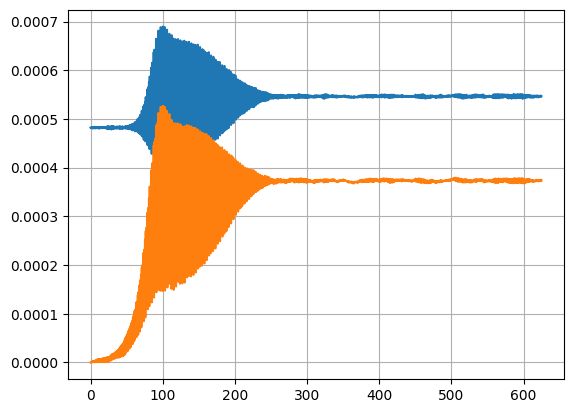

In [4]:
# distances
plt.figure(dpi=100)
plt.grid()

dists = np.sqrt(
    np.square(xs_1 - xs_2) + np.square(ys_1 - ys_2) + np.square(zs_1 - zs_2)
)

dists_xy = np.sqrt(np.square(xs_1 - xs_2) + np.square(ys_1 - ys_2))

plt.plot(
    t,
    dists,
    "-",
)
plt.plot(
    t,
    dists_xy,
    "-",
)

print(np.mean(dists[1000:]))
print(np.mean(dists_xy[1000:]))


plt.show()

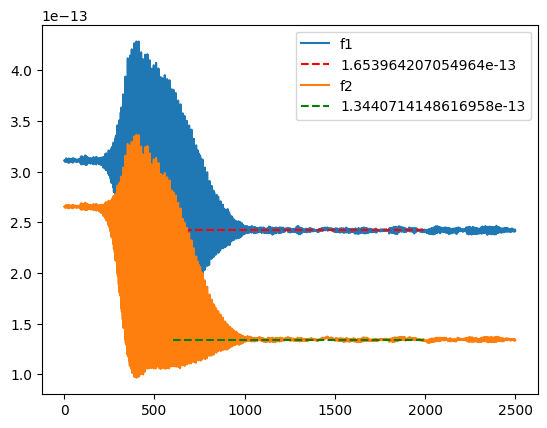

In [5]:
f1x = data[:, 13]
f1y = data[:, 14]
f1z = data[:, 15]

f2x = data[:, 16]
f2y = data[:, 17]
f2z = data[:, 18]

plt.plot(np.sqrt(f1x**2 + f1y**2 + f1z**2), label="f1")
plt.hlines(
    np.mean(np.sqrt(f1x**2 + f1y**2 + f1z**2)[1000:]),
    600,
    2_000,
    linestyles="--",
    colors="red",
    label=f"{np.mean(np.sqrt(f1x**2 + f1y**2)[1000:])}",
)
plt.plot(np.sqrt(f2x**2 + f2y**2 + f2z**2), label="f2")
plt.hlines(
    np.mean(np.sqrt(f2x**2 + f2y**2 + f2z**2)[1000:]),
    600,
    2_000,
    linestyles="--",
    colors="green",
    label=f"{np.mean(np.sqrt(f2x**2 + f2y**2+f2z**2)[1000:])}",
)


plt.legend(loc="best")
plt.show()